In [1]:
import pandas as pd

easy_df = pd.read_csv('data/chem_map_easy_master_v4.csv')
hard_df = pd.read_csv('data/chem_map_hard_master_v4.csv')

In [2]:
attr_column_str = "sequence_length,gc_content,sequence_entropy,average_longest_gc_helix,mfe,ens_def,longest_consecutive_A,longest_consecutive_C,longest_consecutive_G,longest_consecutive_U,avg_gu_pairs,averge_bps_predicted,hairpin_count,helix_count,single_strand_count,junction_count,average_mway_count,longest_singlestrand,average_singlestrand_size,longest_helix,average_helix_size,average_hamming_distance_of_preds,average_au_pairs_of_helices,helices_with_reverse_compliment,rate_of_gt_4_unpaired_nt_in_hairpin"
attr_columns = attr_column_str.split(",")
attr_columns

['sequence_length',
 'gc_content',
 'sequence_entropy',
 'average_longest_gc_helix',
 'mfe',
 'ens_def',
 'longest_consecutive_A',
 'longest_consecutive_C',
 'longest_consecutive_G',
 'longest_consecutive_U',
 'avg_gu_pairs',
 'averge_bps_predicted',
 'hairpin_count',
 'helix_count',
 'single_strand_count',
 'junction_count',
 'average_mway_count',
 'longest_singlestrand',
 'average_singlestrand_size',
 'longest_helix',
 'average_helix_size',
 'average_hamming_distance_of_preds',
 'average_au_pairs_of_helices',
 'helices_with_reverse_compliment',
 'rate_of_gt_4_unpaired_nt_in_hairpin']

In [3]:
from data_utils import pretty_attr_map

pretty_attr_map

{'sequence_length': 'Sequence Length',
 'gc_content': 'GC-Content',
 'sequence_entropy': 'Sequence Entropy',
 'average_longest_gc_helix': 'Longest GC Helix',
 'mfe': 'MFE',
 'ens_def': 'Ensemble Defect',
 'longest_consecutive_A': 'Longest Conesecutive A',
 'longest_consecutive_C': 'Longest Conesecutive C',
 'longest_consecutive_G': 'Longest Conesecutive G',
 'longest_consecutive_U': 'Longest Conesecutive U',
 'avg_gu_pairs': 'GU Pairs',
 'averge_bps_predicted': 'Average Basepairs Predicted',
 'hairpin_count': 'Hairpin Count',
 'helix_count': 'Helix Count',
 'single_strand_count': 'Single Strand Count',
 'junction_count': 'Junction Count',
 'average_mway_count': 'Multiway Junction Count',
 'longest_singlestrand': 'Longest Single Strand',
 'average_singlestrand_size': 'Average Single Strand Size',
 'longest_helix': 'Longest Helix',
 'average_helix_size': 'Average Helix Size',
 'average_hamming_distance_of_preds': 'Average Hamming Distance Between Predictions',
 'average_au_pairs_of_helic

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


def plot_hard_easy_kde(key):
    if key not in easy_df.columns or key not in hard_df.columns:
        raise KeyError(f"Key '{key}' not found in easy_df or hard_df")

    easy_vals = easy_df[key].dropna()
    hard_vals = hard_df[key].dropna()

    plt.figure(figsize=(8, 5))
    sns.kdeplot(data=hard_vals, color='red', label='hard', fill=False)
    sns.kdeplot(data=easy_vals, color='blue', label='easy', fill=False)
    plt.title(f"KDE of {pretty_attr_map.get(key, key)}")
    plt.xlabel(pretty_attr_map.get(key, key))
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
    plt.show()


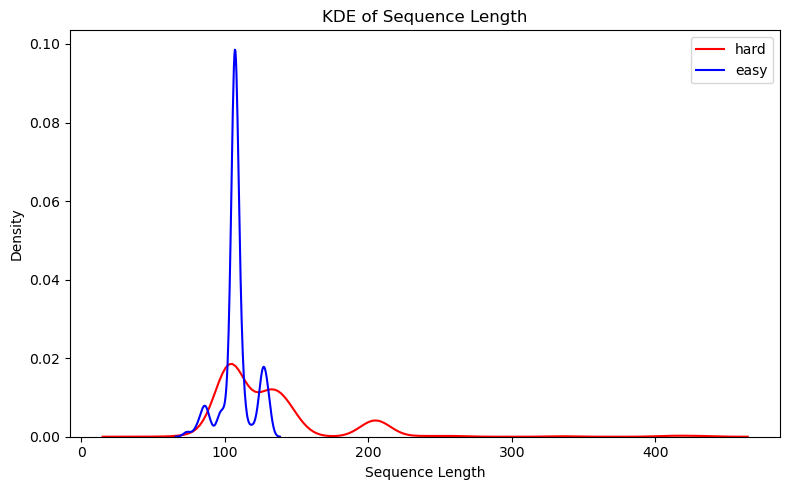

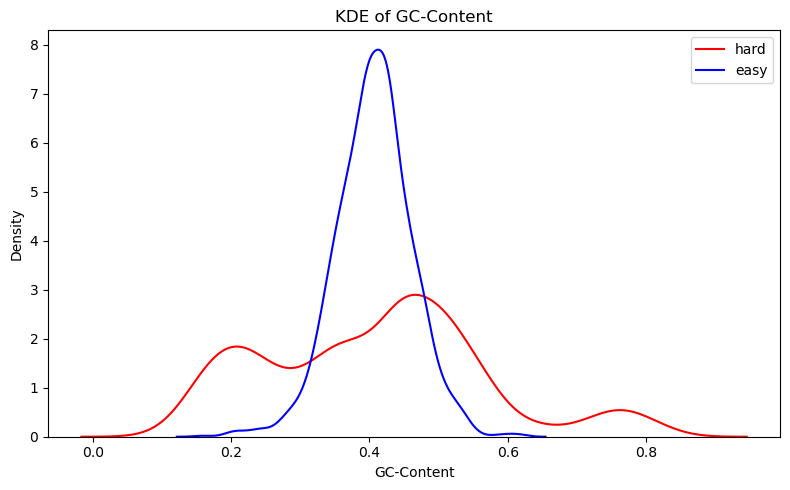

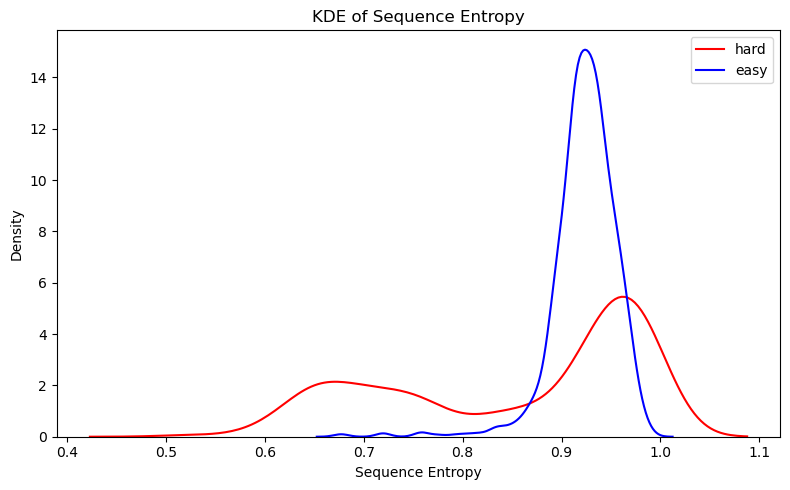

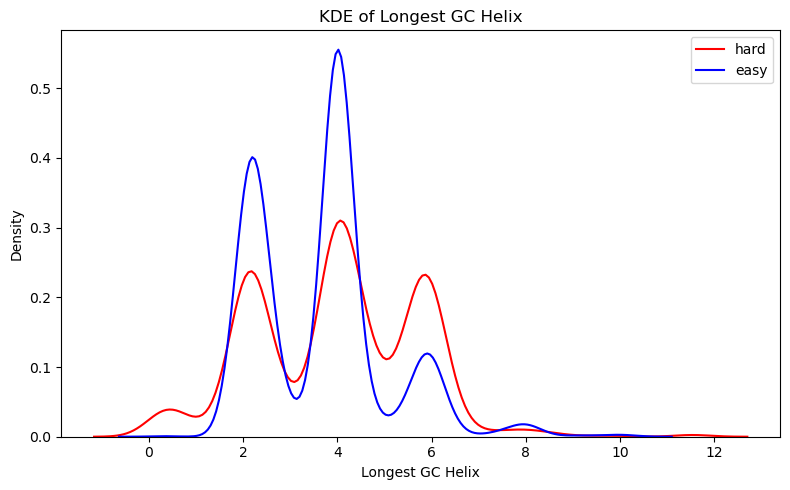

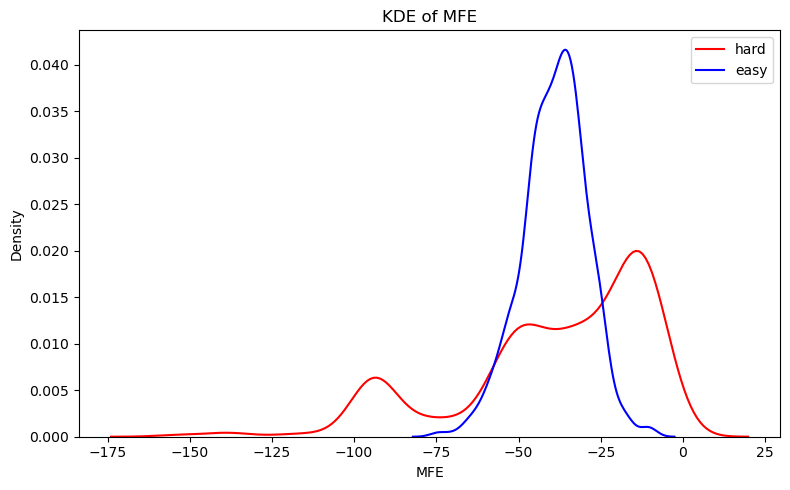

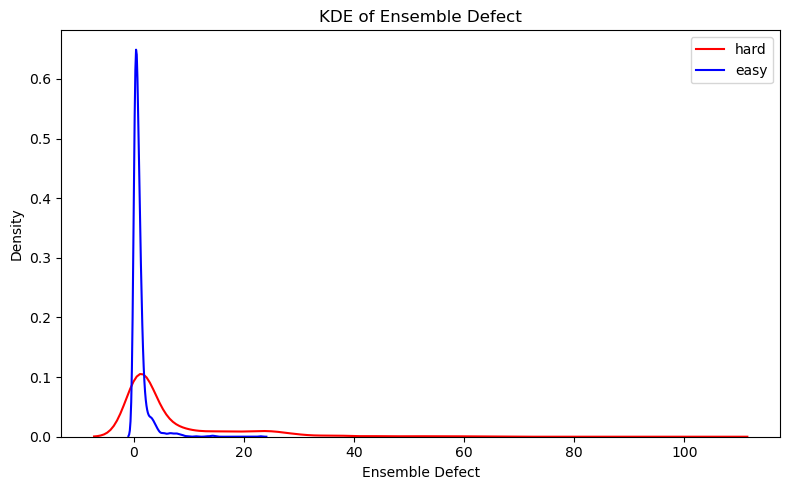

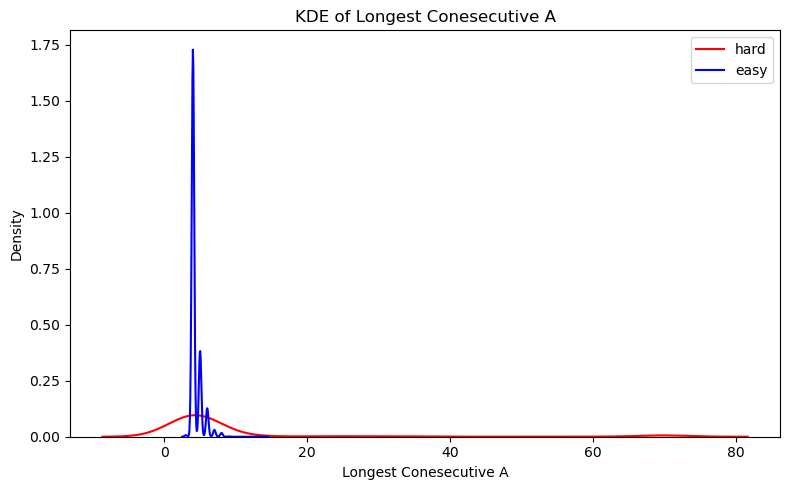

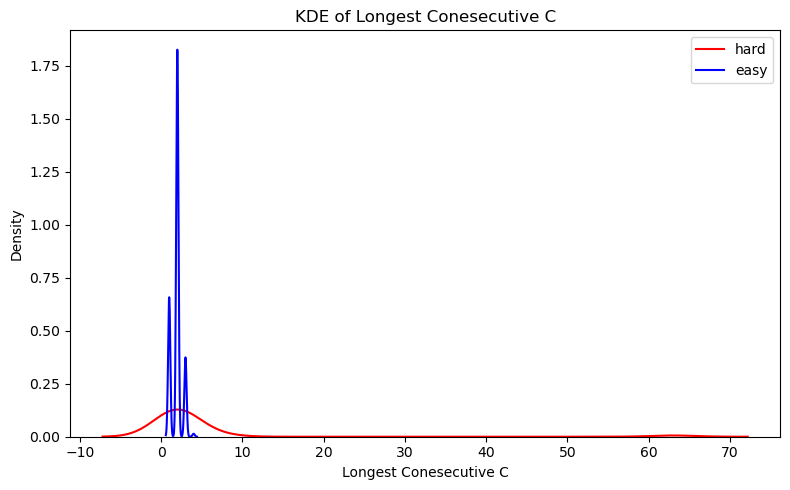

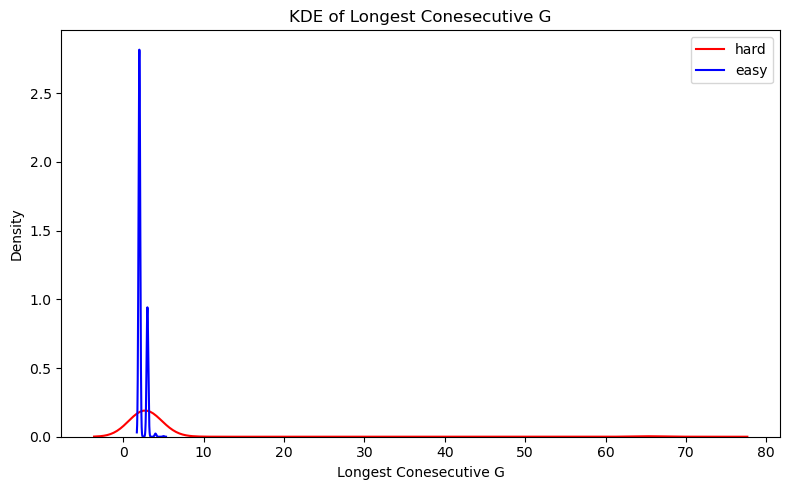

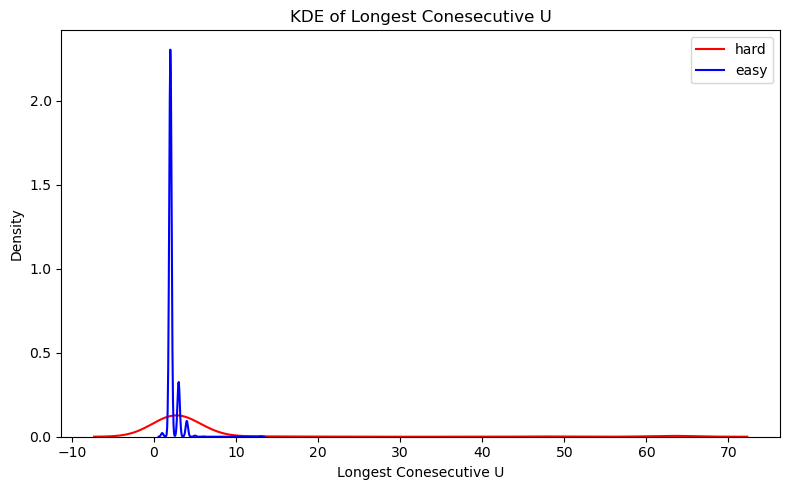

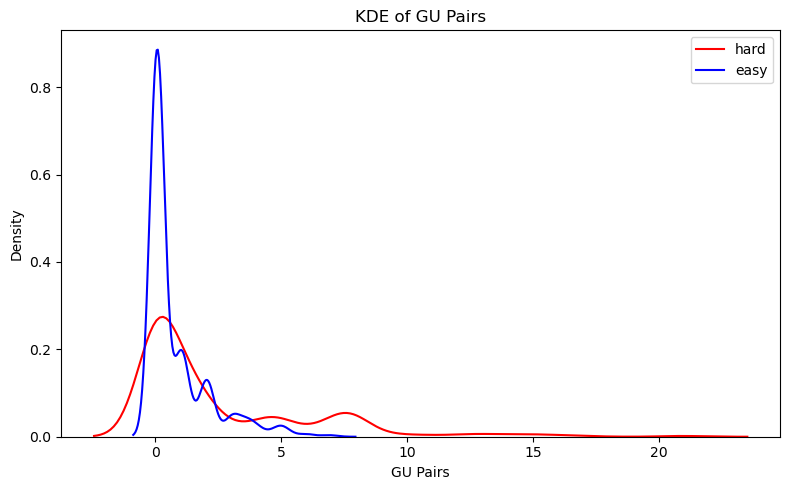

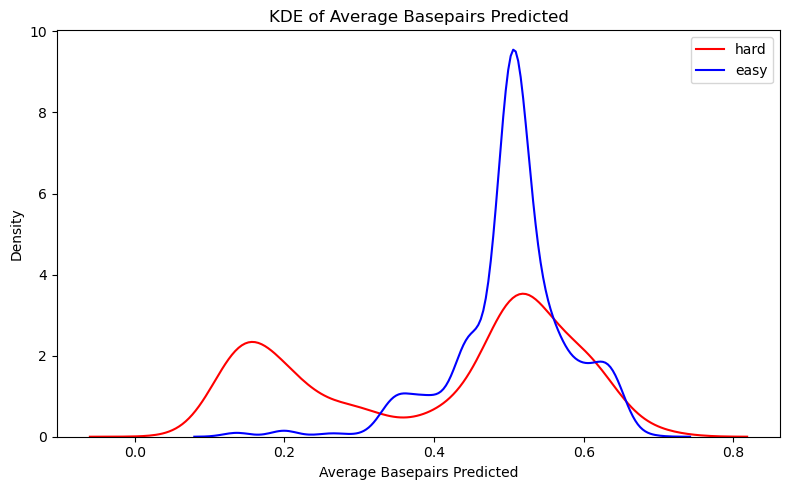

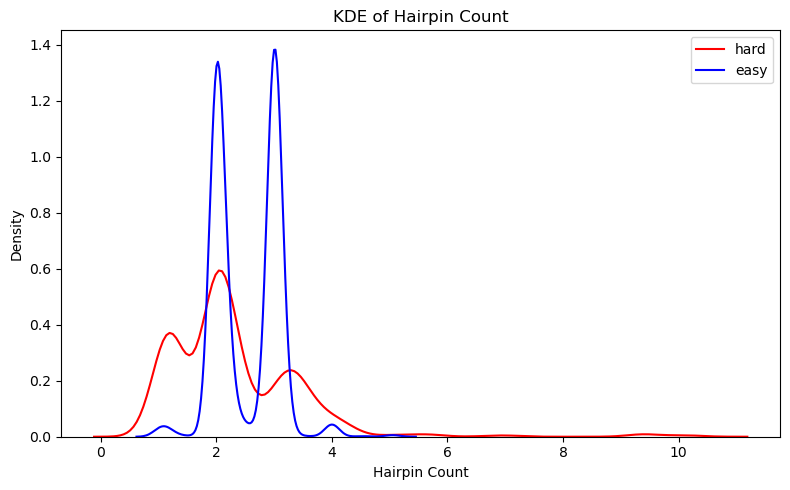

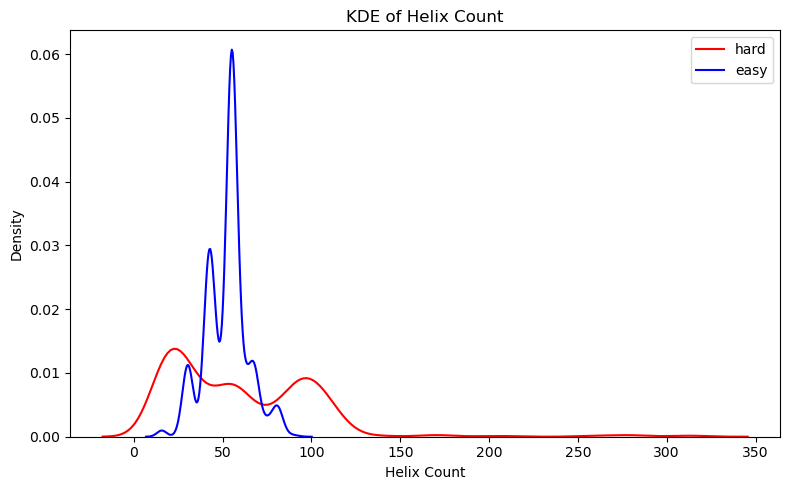

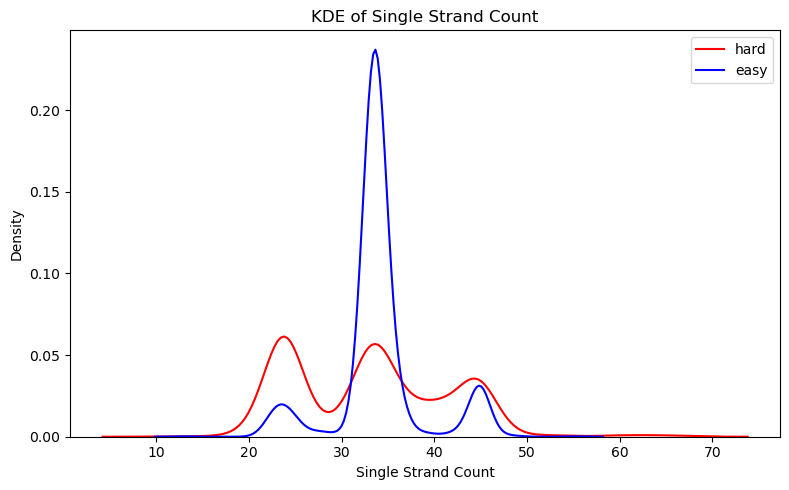

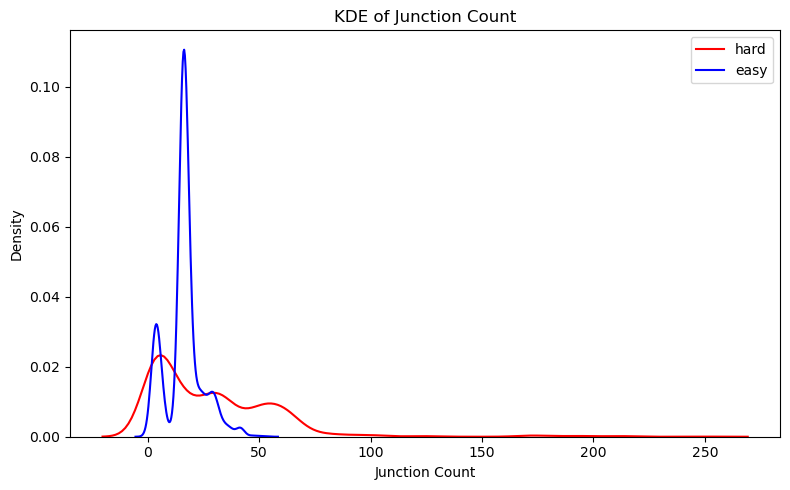

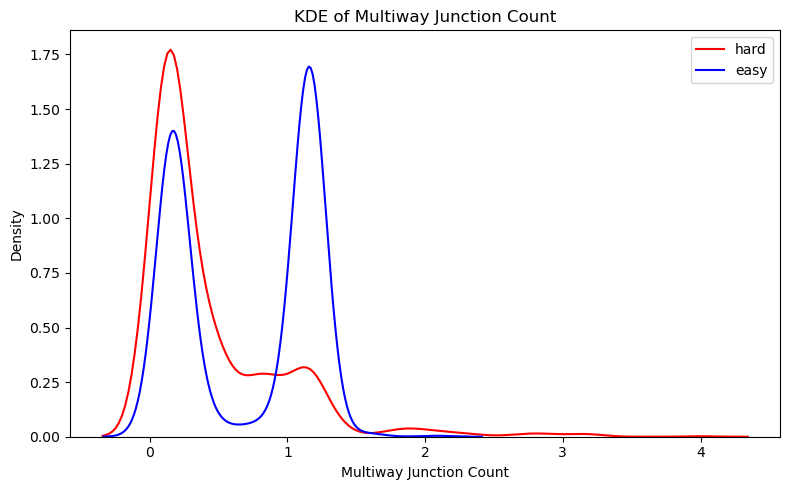

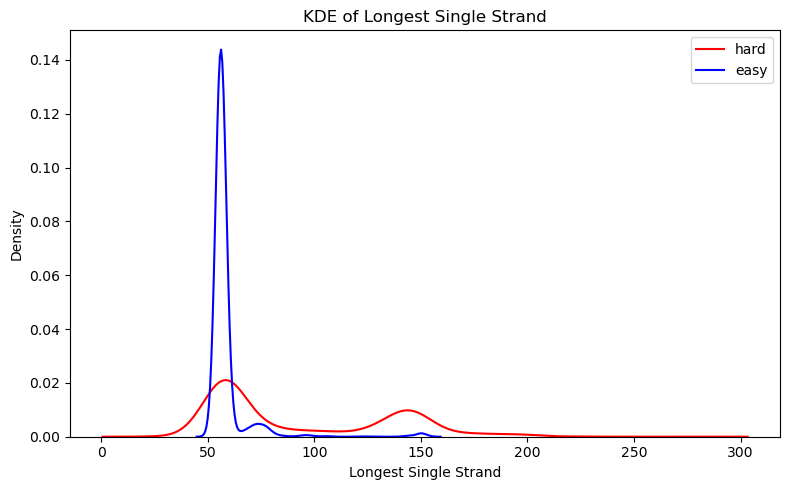

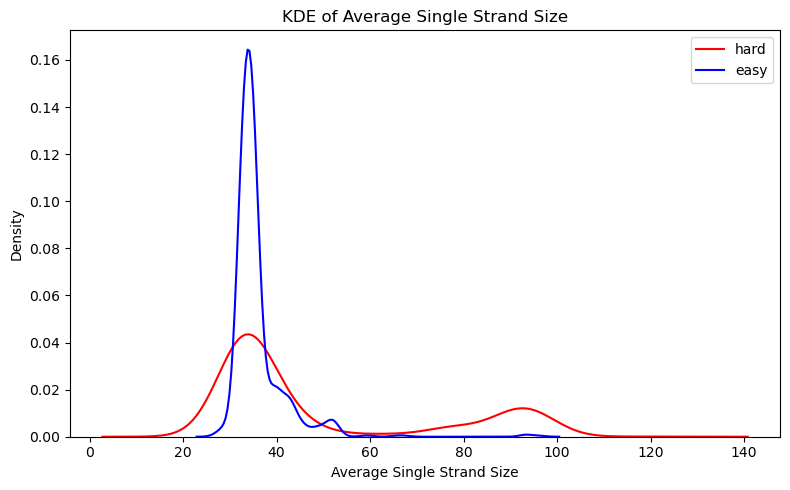

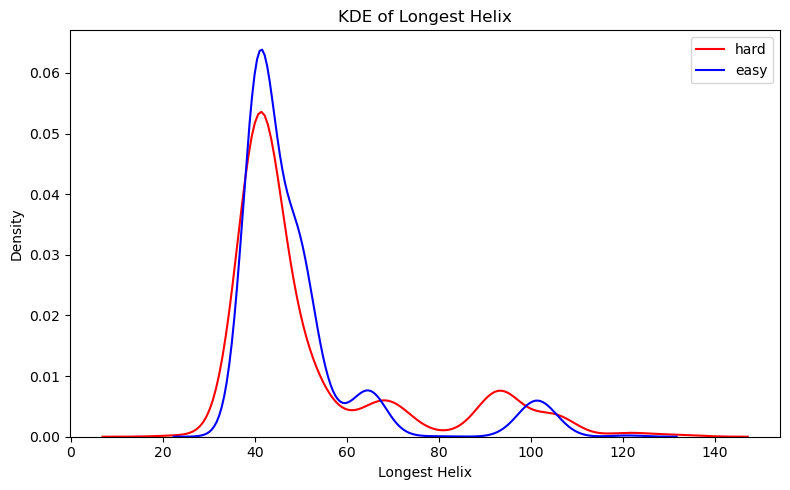

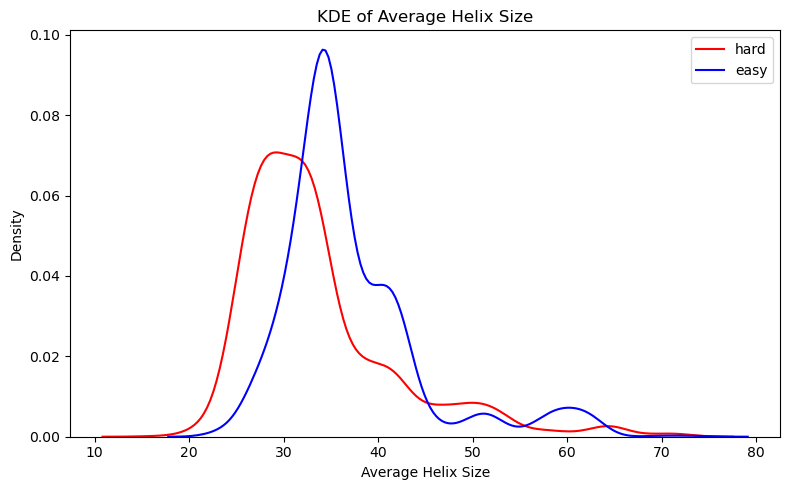

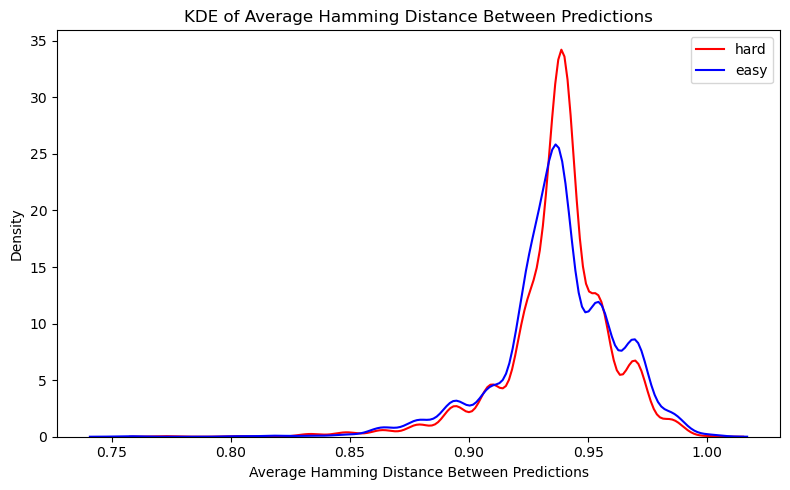

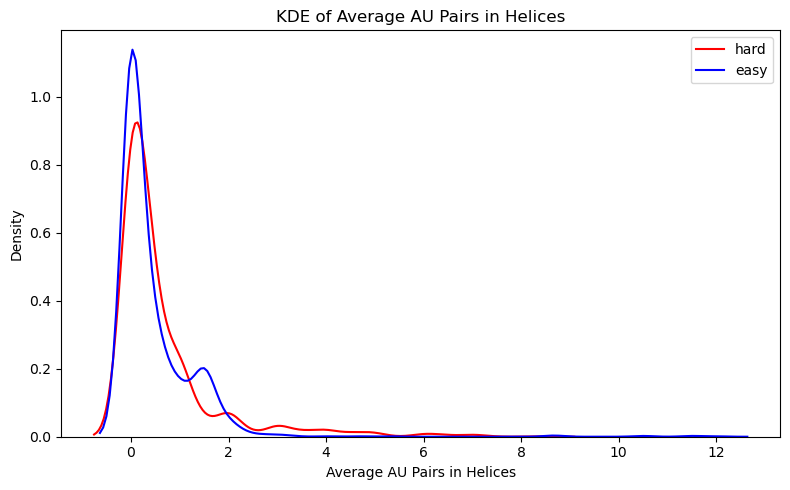

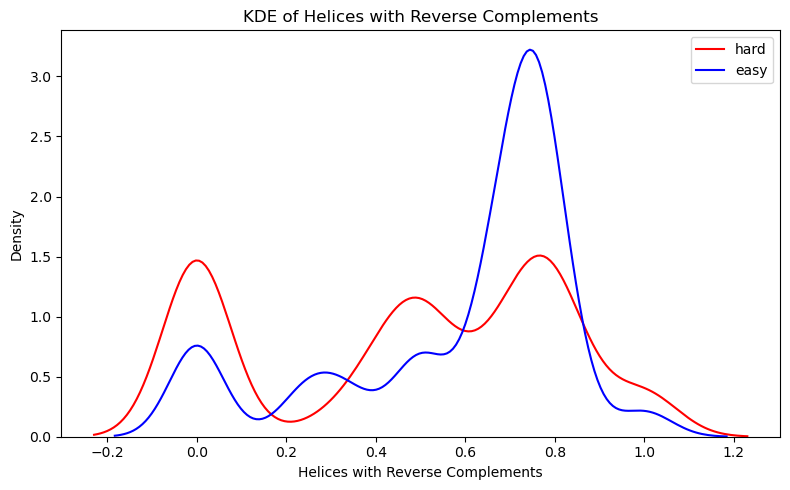

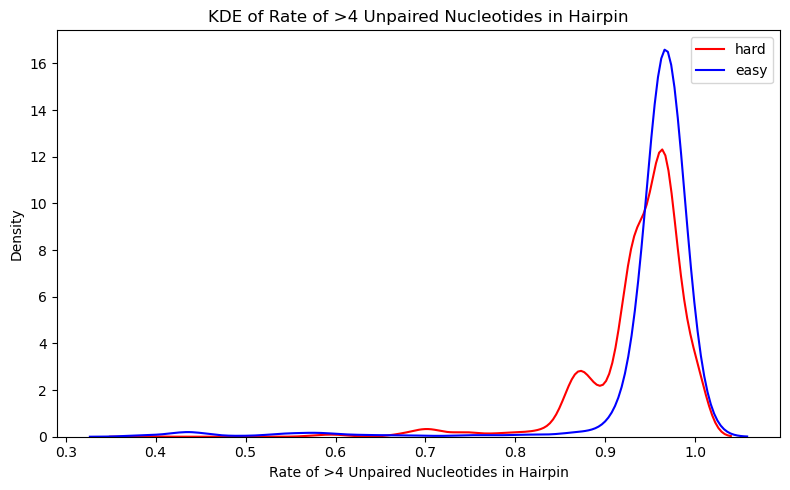

In [5]:
for k in pretty_attr_map:
    plot_hard_easy_kde(k)

In [15]:
attrs_to_plot_with_log = [
    'ens_def',
    'longest_consecutive_A',
    'longest_consecutive_C',
    'longest_consecutive_G',
    'longest_consecutive_U',
]

def plot_hard_easy_kde_with_log(key):
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = 'Arial'
    if key not in easy_df.columns or key not in hard_df.columns:
        raise KeyError(f"Key '{key}' not found in easy_df or hard_df")

    easy_vals = easy_df[key].dropna()
    hard_vals = hard_df[key].dropna()
    use_log_scale = key in attrs_to_plot_with_log

    plt.figure(figsize=(8, 5))
    sns.kdeplot(data=hard_vals, color='red', label='hard', fill=False)
    sns.kdeplot(data=easy_vals, color='blue', label='easy', fill=False)
    plt.title(f"KDE of {pretty_attr_map.get(key, key)}")
    plt.xlabel(pretty_attr_map.get(key, key))
    plt.ylabel('Density')
    if use_log_scale:
        plt.xscale('log')
    plt.legend()
    plt.tight_layout()
    plt.show()

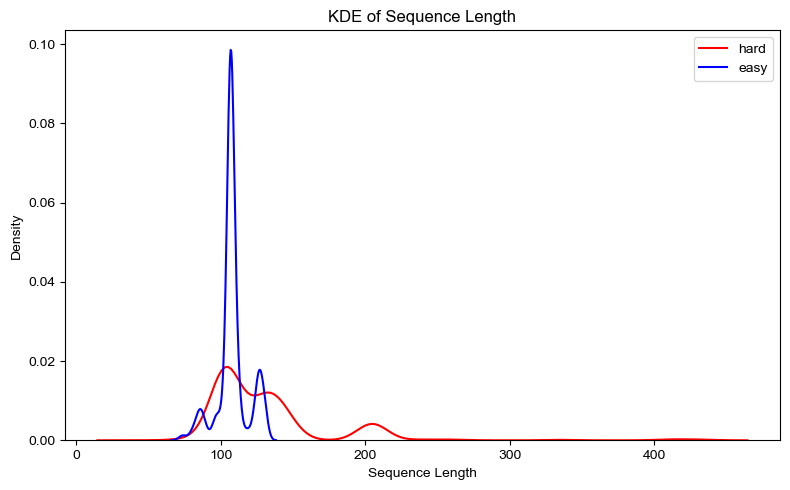

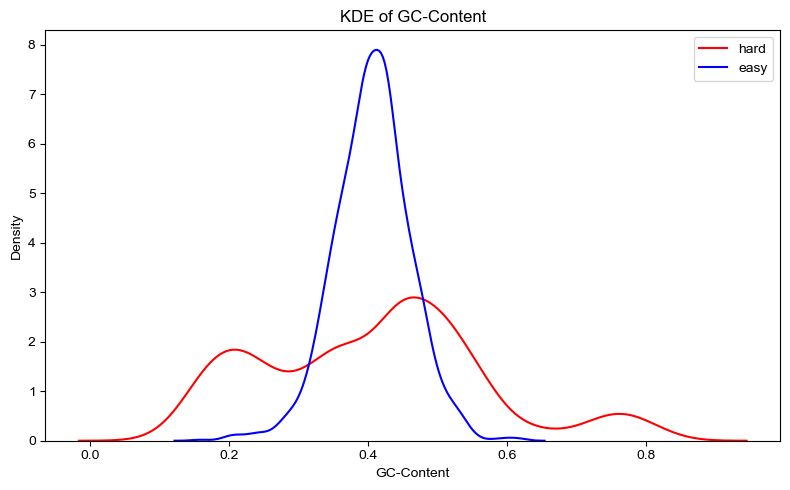

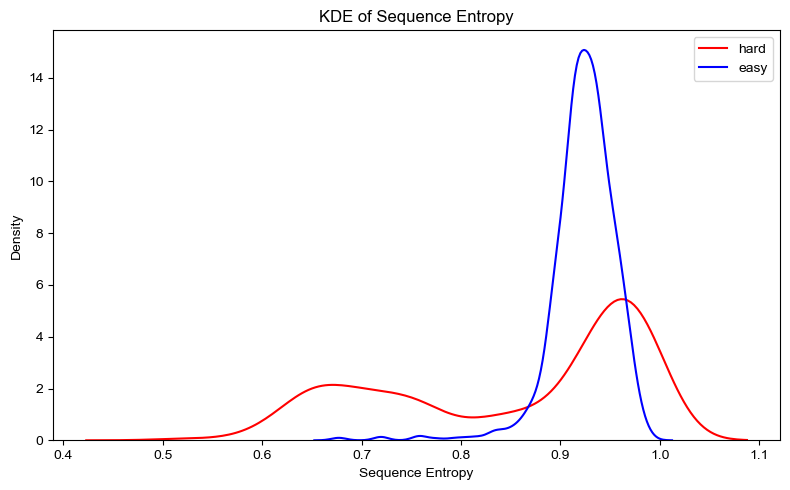

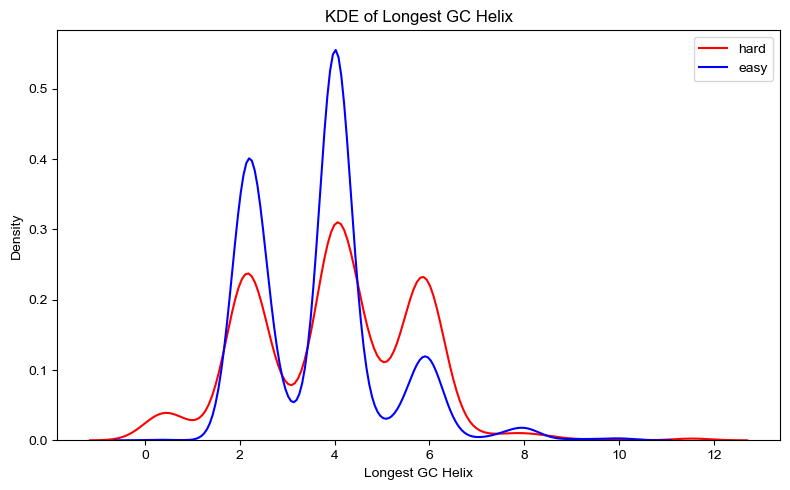

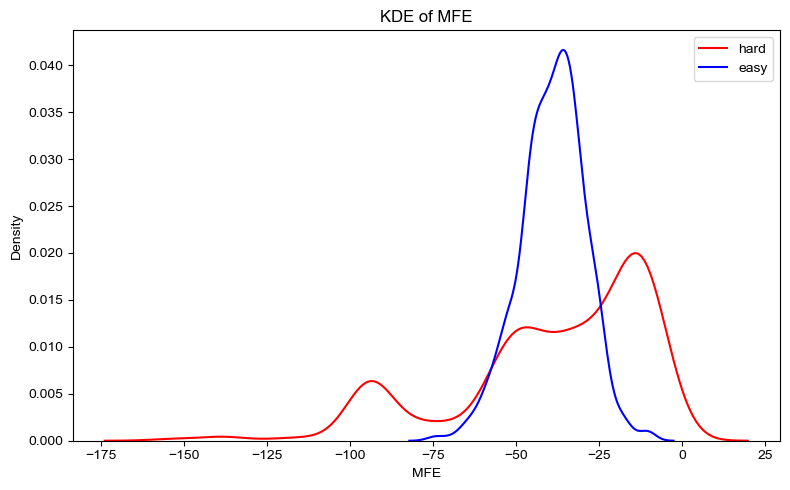

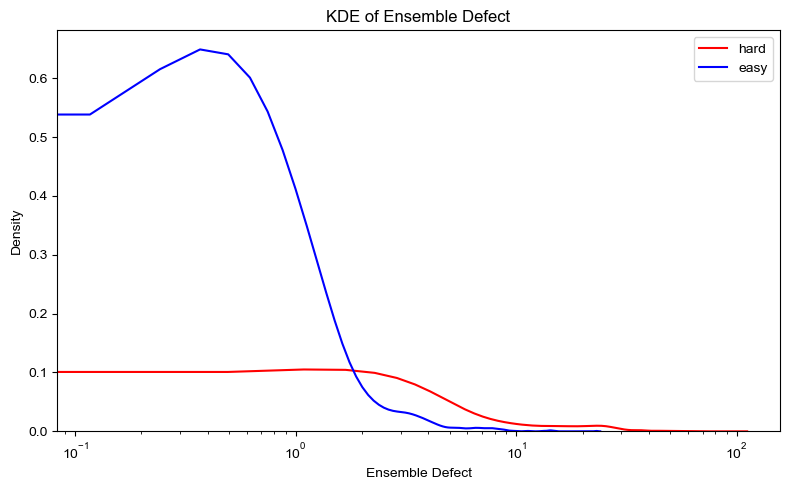

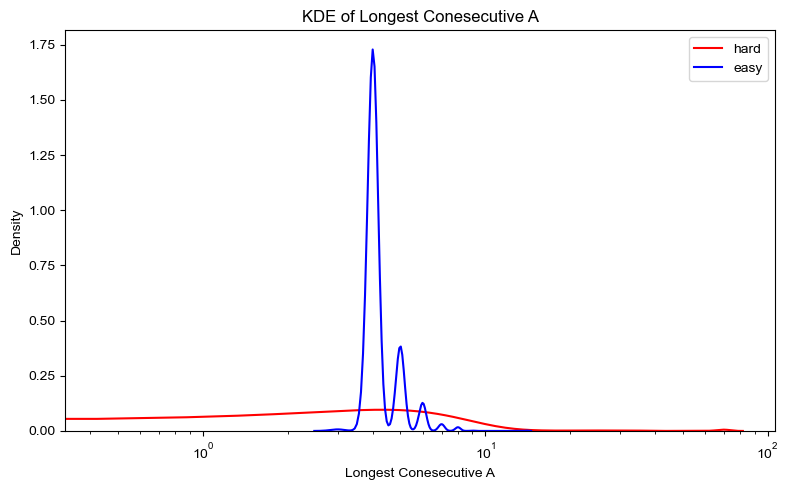

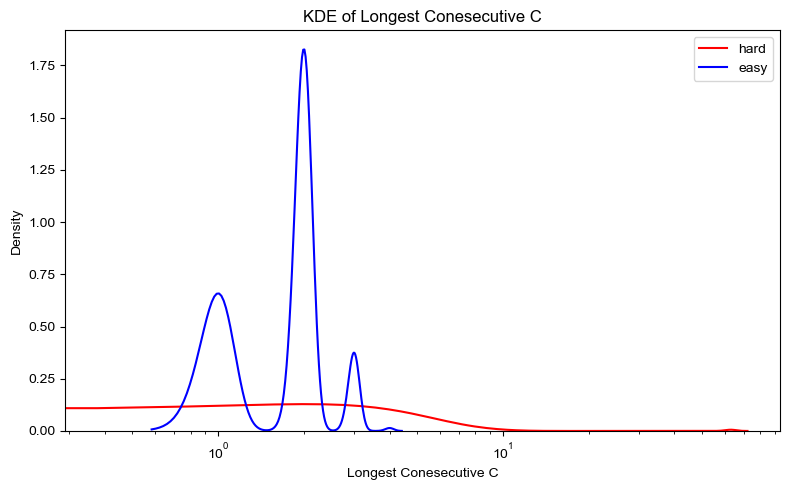

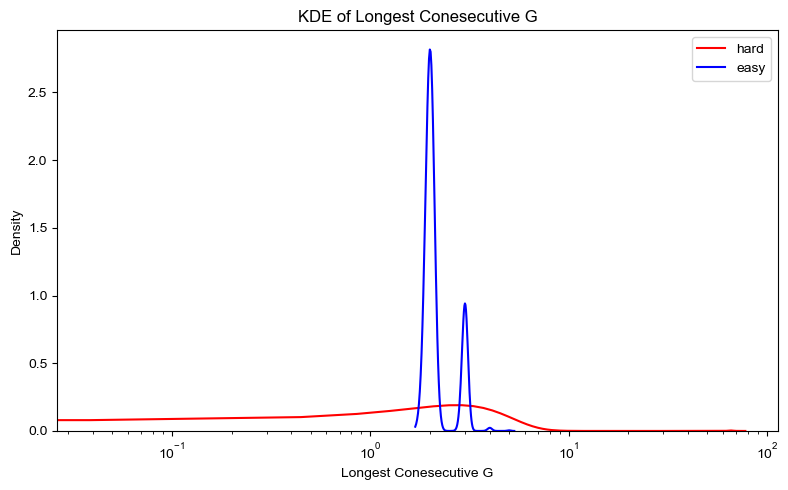

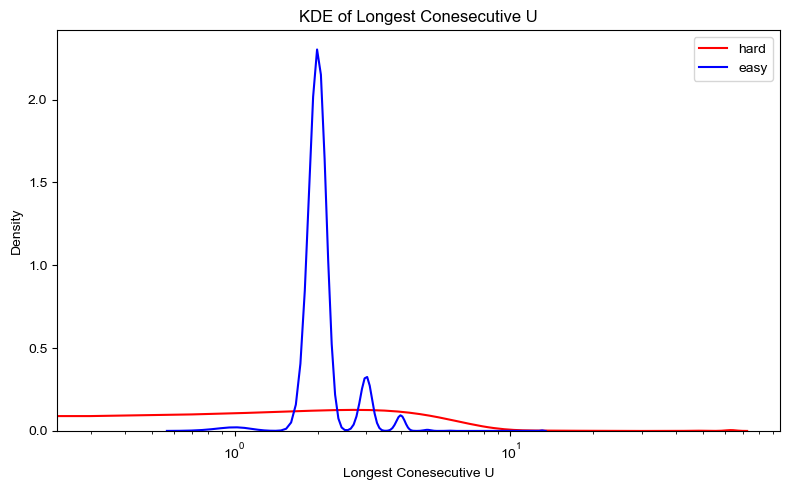

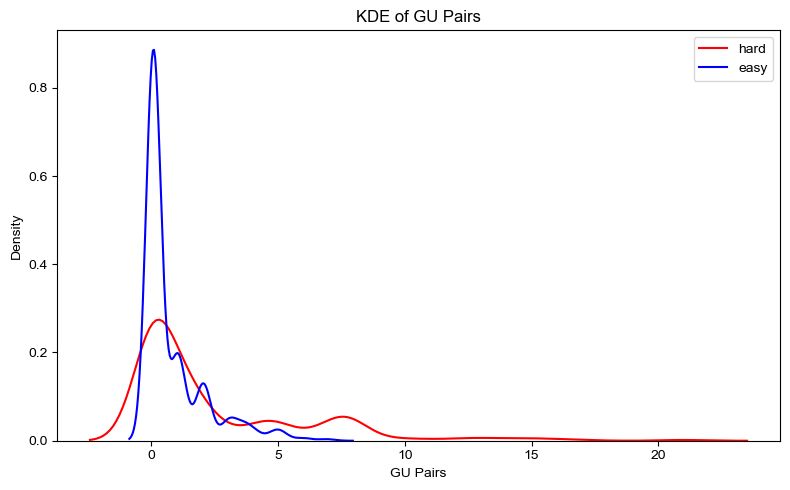

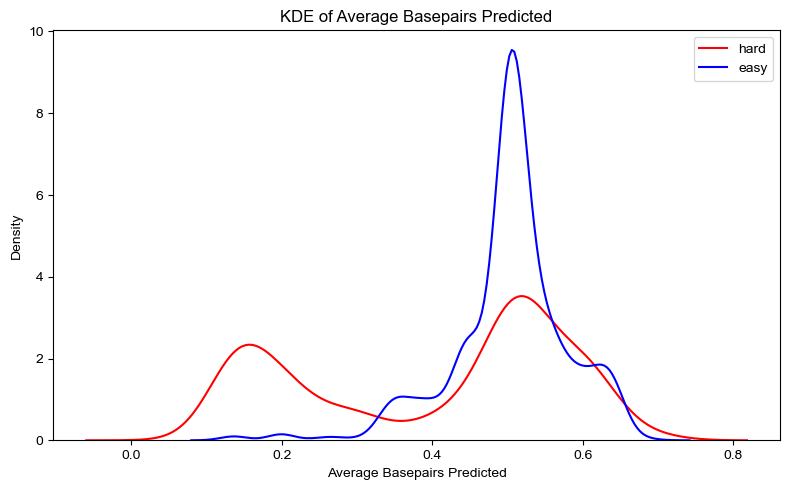

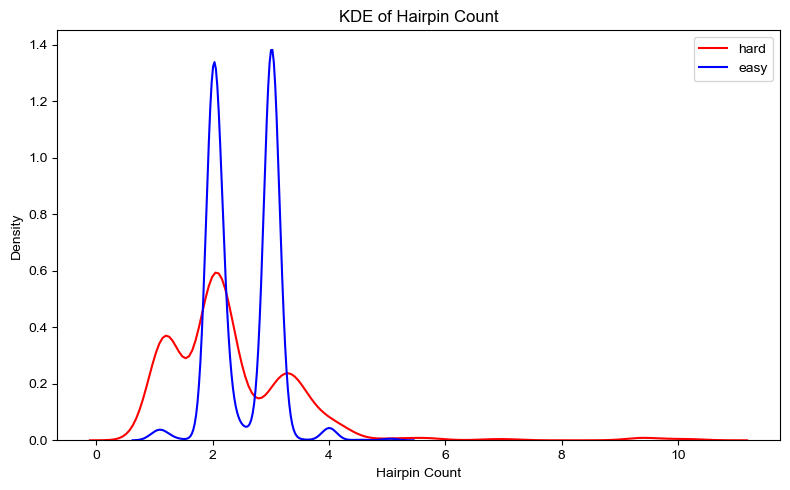

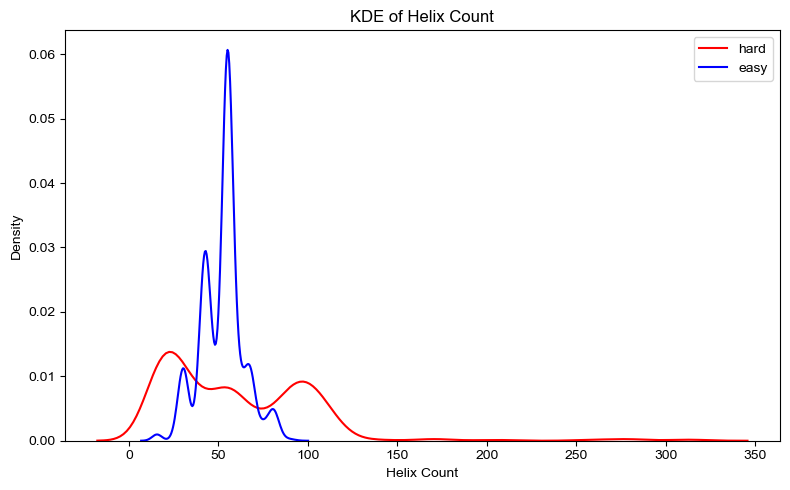

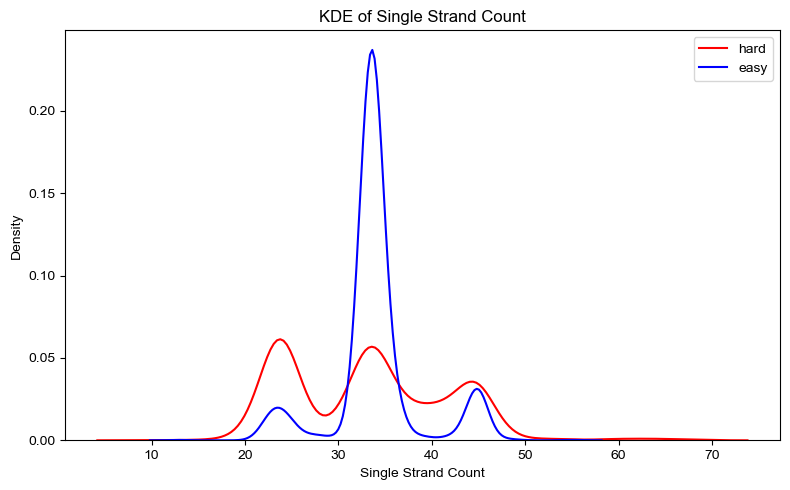

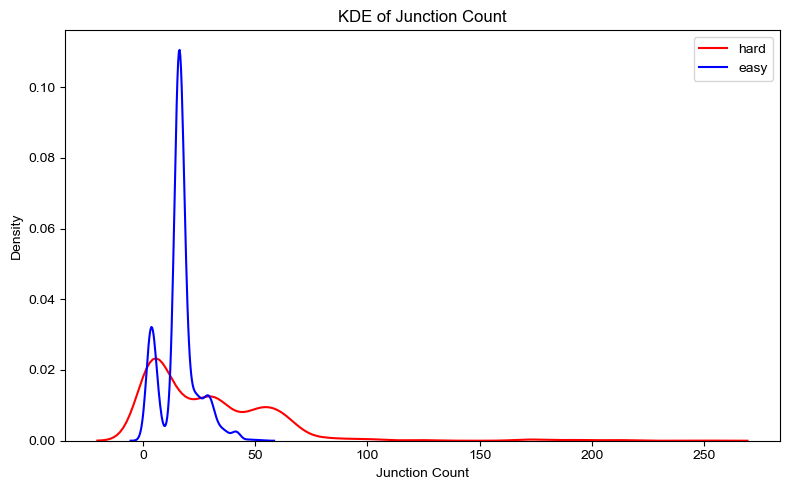

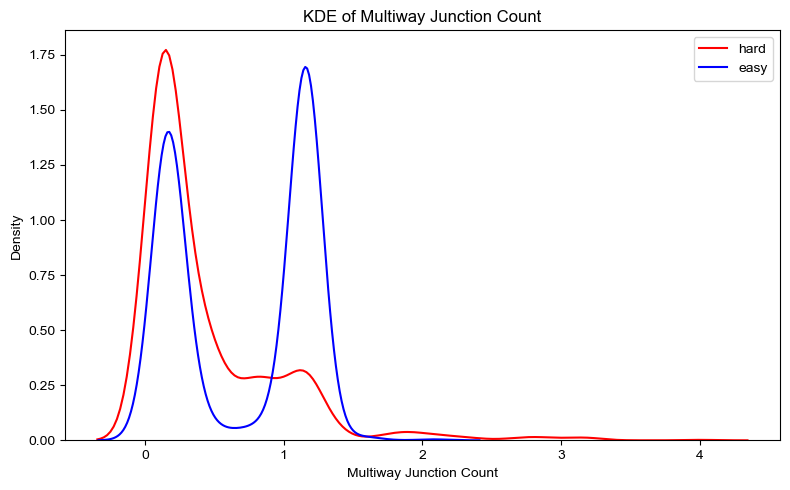

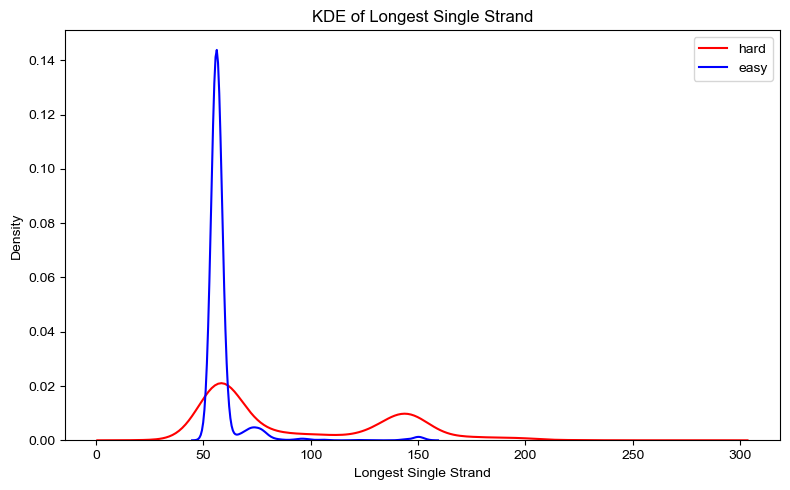

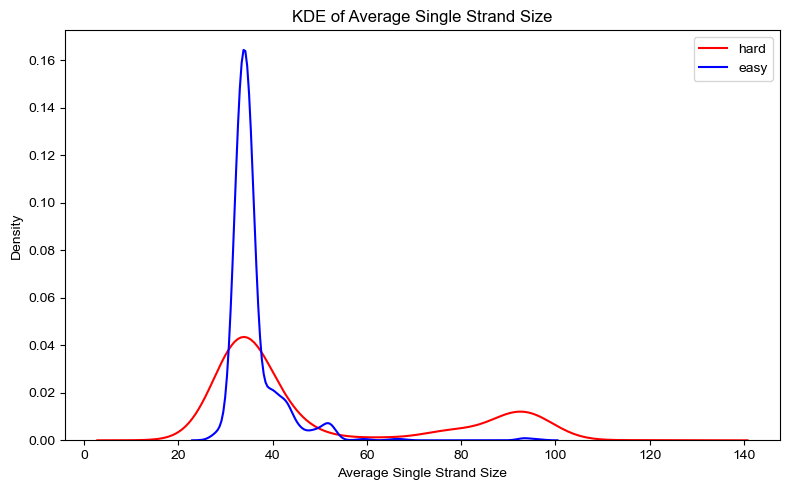

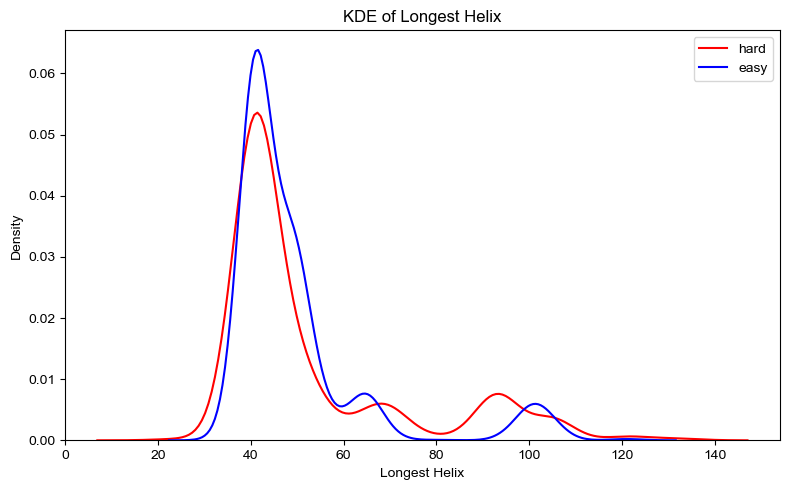

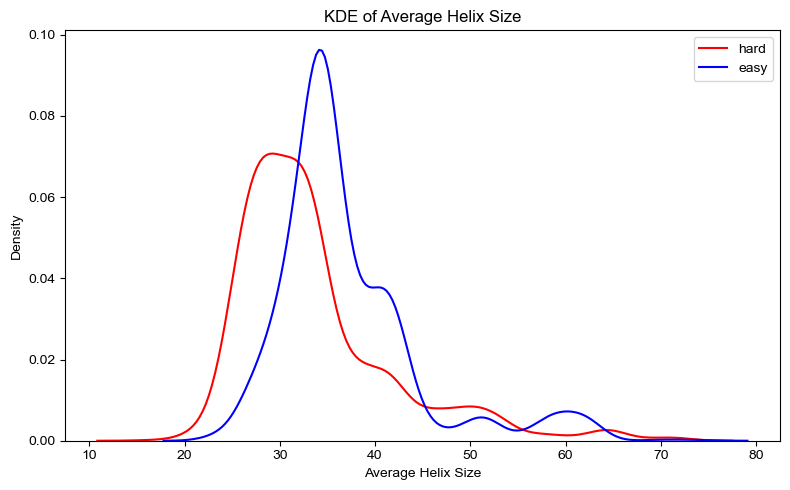

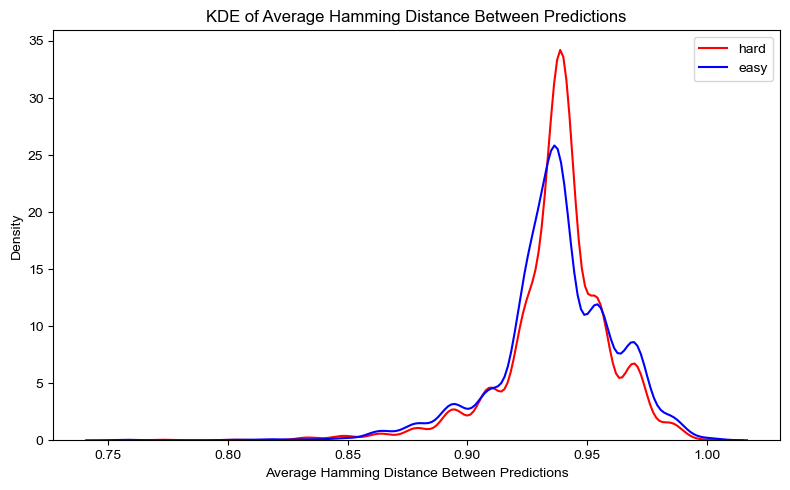

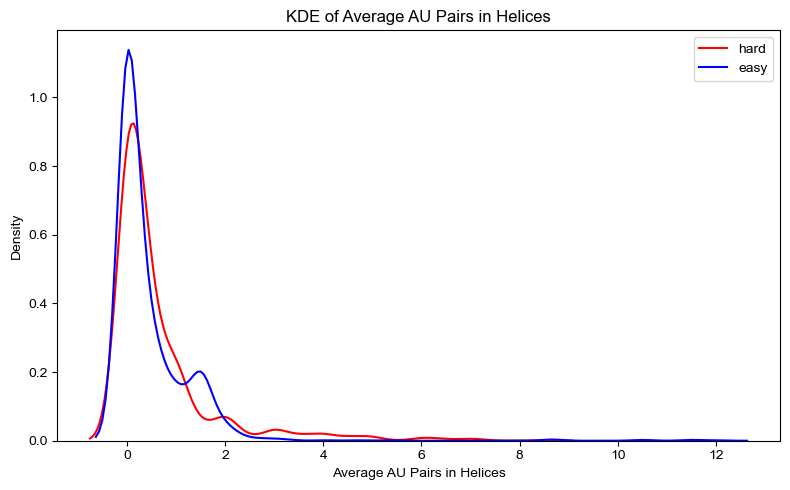

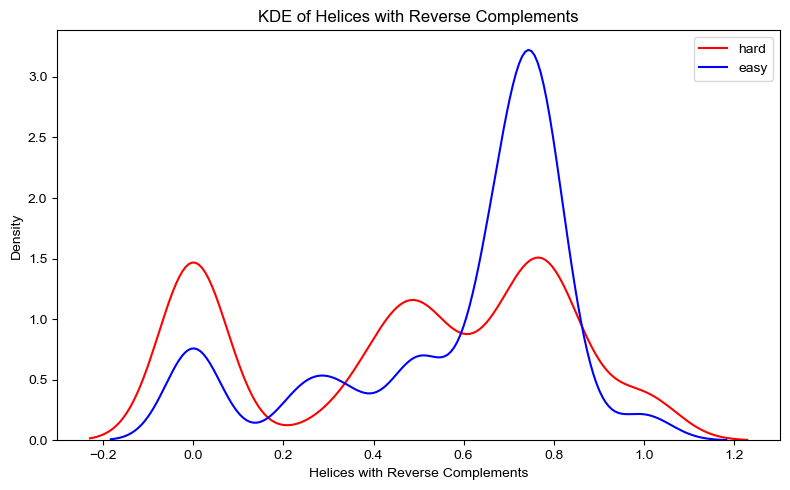

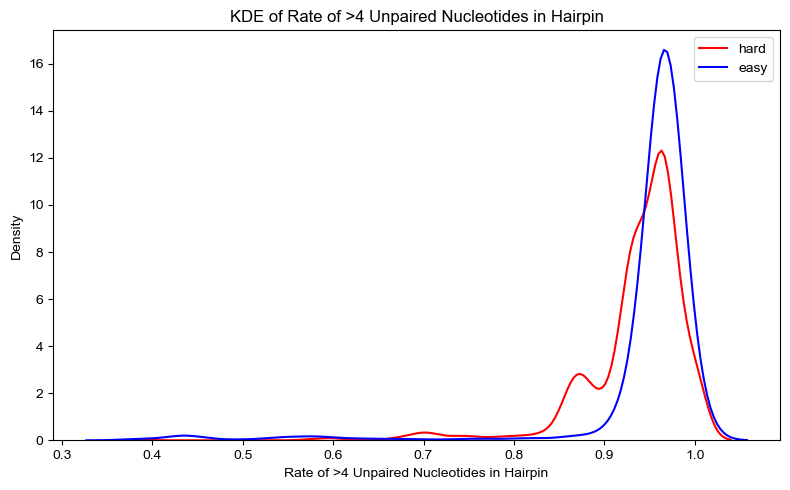

In [16]:
for k in pretty_attr_map:
    plot_hard_easy_kde_with_log(k)